In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#05-07-2026 - 07-07-2026
raw_data=pd.read_excel(r'C:\Users\jlhb1\OneDrive\Documentos\Zonar_projects\data\cea\WEZ84G.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1478 non-null   str  
 1   Message  1478 non-null   str  
 2   Status   1478 non-null   str  
dtypes: str(3)
memory usage: 34.8 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    1459
0x252514      12
0x252501       4
0x252511       3
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1478 non-null   str  
 1   Message  1478 non-null   str  
 2   Status   1478 non-null   str  
 3   Headers  1478 non-null   str  
dtypes: str(4)
memory usage: 46.3 KB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1477
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1471 non-null   str  
 1   Message             1471 non-null   str  
 2   Status              1471 non-null   str  
 3   Headers             1471 non-null   str  
 4   Odometer in meters  1471 non-null   int64
 5   Date                1471 non-null   str  
 6   Raw data            1471 non-null   str  
dtypes: int64(1), str(6)
memory usage: 91.9 KB
None


260705002946 -> 0 -> 4381379.0 -> 0x2525130059E9D10869487064399040001EFFFF2D0000003A4900000007000020000000FFFFFFFFFFFFFFFFFFFF00D50042DAC3962607050029469A39BD44FD3397C29CFBC7400060003F03891290FFFFFF00001D0001FFFFFF
260705003000 -> 1 -> 4381383.0 -> 0x2525130059E9D20869487064399040001EFFFF2D0000003E4800000007000020000000FFFFFFFFFFFFFFFFFFFF00D50042DAC7962607050030003303BD44013497C293FBC740005000F903891290FFFFFF00001E0001FFFFFF
260705011702 -> 2 -> 4381400.0 -> 0x2525130059E9D30869487064399040001EFFFF2D000000414900000007000020000000FFFFFFFFFFFFFFFFFFFF00D50042DAD8962607050117020080BC44F63397C209FBC7400090003303891290FFFFFF00001C0001FFFFFF
260705011705 -> 3 -> 4381403.0 -> 0x2525130059E9D40869487064399040001EFFFF2D0000003A4900000007000020000000FFFFFFFFFFFFFFFFFFFF00D50042DADB9626070501170533D3BC44F43397C239FBC740007000F703891288FFFFFF00001E0001FFFFFF
260705011730 -> 4 -> 4381419.0 -> 0x2525130059E9D50869487064399040001EFFFF2D000000334900000007000020000000FFFFFFFFFFFFFFFFFFFF00D50042DAEB96

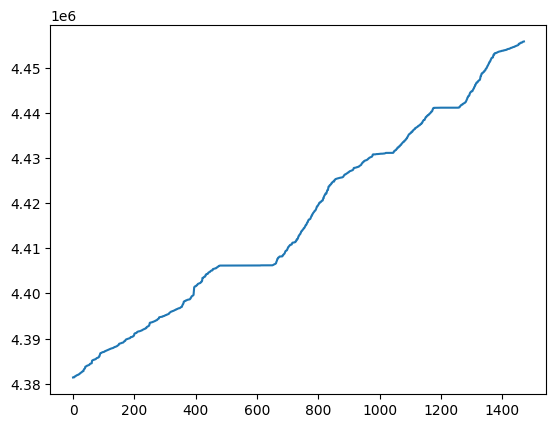

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [7]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1464 entries, 0 to 1451
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     1464 non-null   int64
 1   Date      1464 non-null   str  
 2   Raw data  1464 non-null   str  
dtypes: int64(1), str(2)
memory usage: 45.8 KB
None


260706040611 -> 421 -> 162.0 -> 0x2525130059EB760869487064399040001EFFFF2D000000374400000007000020000000FFFFFFFFFFFFFFFFFFFF00D500432EBD952607060406119A69C444583497C210F7C740162000F003881281FFFFFF00001C0006FFFFFF
260706213225 -> 660 -> 165.0 -> 0x2525130059EC640869487064399040001EFFFF2D000000444500000007000020000000FFFFFFFFFFFFFFFFFFFF00D500433DC69826070621322500C0B944313497C219FCC7401650012F03891303FFFFFF0000210002FFFFFF


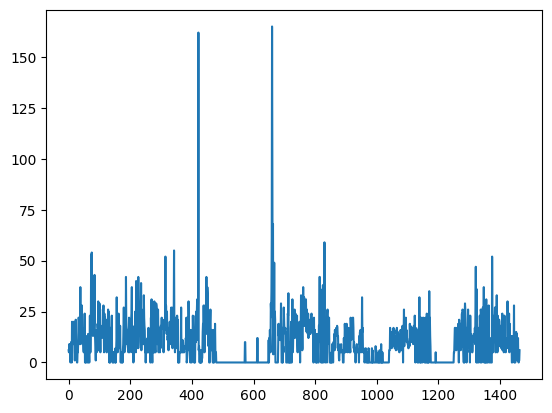

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #if (float(unit.iloc[i,0]))>100:
    #    print(raw_data_[i])
    
for i in range(0,len(speed)):
    if (y_axis[i]>100):
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])
        
plt.plot(x_axis,y_axis)

Satellites

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1477
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         1471 non-null   str  
 1   Message                         1471 non-null   str  
 2   Status                          1471 non-null   str  
 3   Headers                         1471 non-null   str  
 4   Satellites                      1471 non-null   int64
 5   Satellite_connection_indicator  1471 non-null   int64
 6   Raw data                        1471 non-null   str  
 7   date                            1471 non-null   str  
dtypes: int64(2), str(6)
memory usage: 103.4 KB
2026-07-06 14:16:45.031 -> 0 -> 0 -> 0x2525130059EC390869487064399040001EFFFF2D000000330000000007000061000000FFFFFFFFFFFFFFFFFFFF00D500433BE39626070614164382DC00650800879761B60054000A003703891425FFFFFF000036FFFFFFFFFF
2026-07-06 14:32:39.744 -> 0 -> 0 -> 0x2525130059EC580

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1386
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1471 non-null   str  
 1   Message  1471 non-null   str  
 2   Status   1471 non-null   str  
 3   Headers  1471 non-null   str  
dtypes: str(4)
memory usage: 57.5 KB


Power

In [11]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1386
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1471 non-null   str  
 1   Message  1471 non-null   str  
 2   Status   1471 non-null   str  
 3   Headers  1471 non-null   str  
dtypes: str(4)
memory usage: 57.5 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [12]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1386
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1471 non-null   str  
 1   Message  1471 non-null   str  
 2   Status   1471 non-null   str  
 3   Headers  1471 non-null   str  
dtypes: str(4)
memory usage: 57.5 KB
len aux_cad:  1471
